# Token Consumption Lab

## What this shows

Claude's token cost changes with four settings you control as a Claude Code user:

| Setting group | What varies |
|---|---|
| **Model** | `haiku` vs `sonnet` vs `opus` — different price-per-token |
| **Effort** | `low` → `max` — more reasoning = more output tokens |
| **Caching** | A long repeated prefix read from cache vs re-billed as new input |
| **Context size** | A short vs a stuffed context window |

## How to read this notebook

You are reading **measured numbers** (or clearly-labelled illustrative samples
until a real run replaces them).  The presentation cells below — the table and
the charts — run **without an API key** from a committed CSV file.

Re-running the live measurement is optional and is gated behind its own cell
near the bottom.  It needs your own `ANTHROPIC_API_KEY` and costs a few US cents.


In [1]:
# Load and display the tidy results table.
# Reads results.csv (real run) if present, else results.sample.csv (placeholder).
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))  # ensure token_lab is importable

import token_lab
import pandas as pd

df = token_lab.load_results()
df


No results.csv found — using illustrative sample: C:\Onedrive\Personal\OneDrive\Famnit\IMB2026\claude-code-workshop\notebook\results.sample.csv


,setting_group,setting,input_tokens,output_tokens,cached_input_tokens,usd_cost,latency_s
0,model,opus,1500,600,0,0.0225,6.0
1,model,sonnet,1500,600,0,0.0135,3.5
2,model,haiku,1500,600,0,0.0045,2.0
3,effort,low,1500,300,0,0.0150,4.0
4,effort,medium,1500,600,0,0.0225,6.0
5,effort,high,1500,1200,0,0.0375,10.0
6,effort,xhigh,1500,2000,0,0.0575,16.0
7,effort,max,1500,3000,0,0.0825,24.0
8,caching,uncached,8000,400,0,0.0500,7.0
9,caching,cached,200,400,8000,0.0150,4.0


chart_model.png


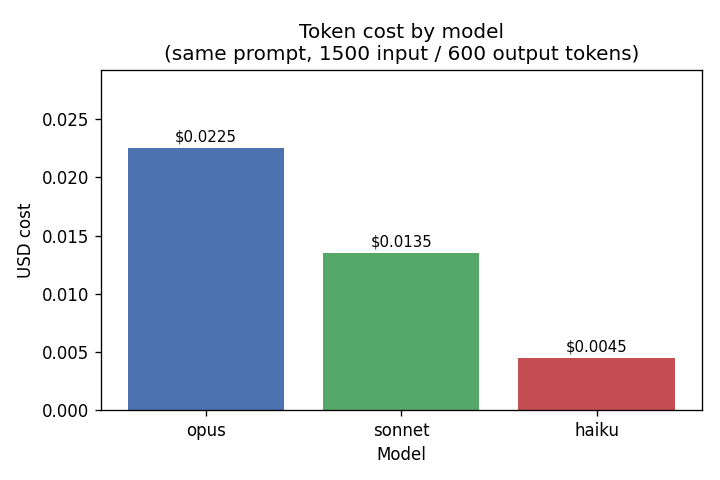

chart_effort.png


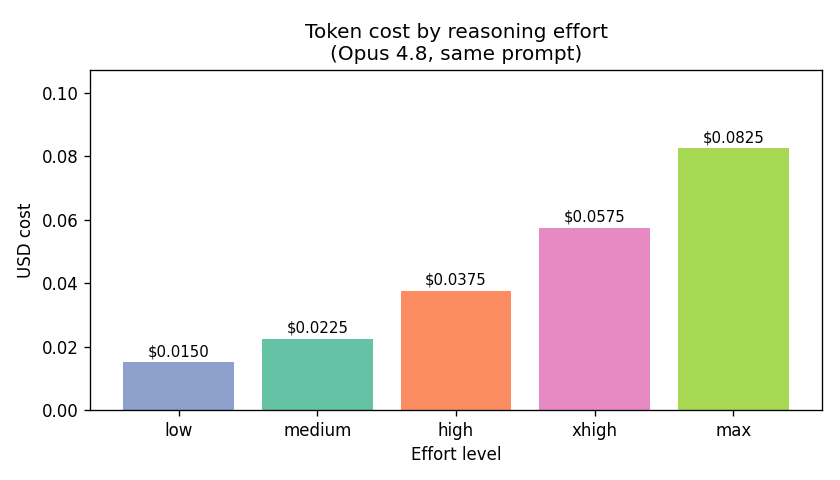

chart_caching.png


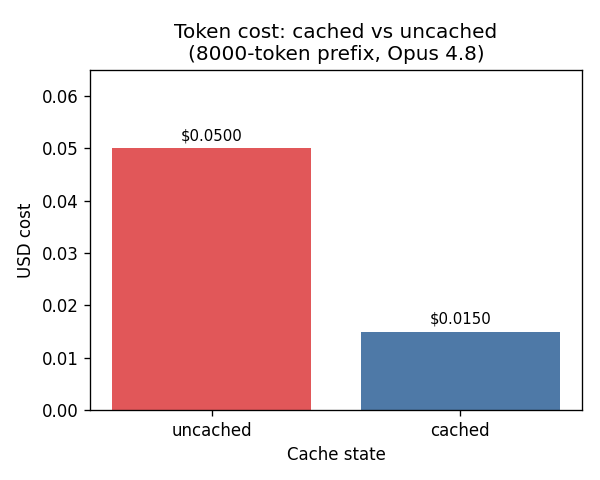

In [2]:
# Render the three comparison charts and display them inline.
import os
import token_lab
from IPython.display import Image, display

chart_paths = token_lab.make_charts(df, '.')
for p in chart_paths:
    print(p)
    display(Image(filename=p))


## Optional: measure it yourself

The cell below sends real API requests and overwrites `results.csv` with fresh
measurements.

**Requirements:**
- Set the environment variable `ANTHROPIC_API_KEY` to your key before running.
- The live sweep covers ~10 API calls across all setting groups.
  Estimated cost: **< $0.10** with default prompts.
- After running, re-execute the cells above to see your real numbers.

If `ANTHROPIC_API_KEY` is not set, the cell skips gracefully and the notebook
continues to display the committed results.


In [3]:
# GATED: live API measurement — only runs when ANTHROPIC_API_KEY is set.
import os
import token_lab
import anthropic

KEY = os.environ.get("ANTHROPIC_API_KEY")
if not KEY:
    print("No ANTHROPIC_API_KEY found — skipping live measurement; reading committed results.")
else:
    print("API key found — starting live measurement (may take ~60 s) ...")
    client = anthropic.Anthropic()
    res = token_lab.measure_settings(client)
    res.to_csv("results.csv", index=False)
    print("Wrote results.csv")
    print(res.to_string(index=False))


No ANTHROPIC_API_KEY found — skipping live measurement; reading committed results.
